**Cell 1 — Import Libraries**

In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import json

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# MLflow
import mlflow
import mlflow.sklearn

**Cell 2 — Download NLTK Data**

In [4]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

**Cell 3 — Load Configuration File**

In [6]:
import os
print(os.getcwd())

/content


In [7]:
!ls

legal_notices.csv  sample_data


In [9]:
import json

config = {
    "random_seed": 42,
    "test_size": 0.2,
    "max_features": 5000,

    "model_1": {
        "name": "LogisticRegression",
        "C": 1.0,
        "max_iter": 1000
    },

    "model_2": {
        "name": "MultinomialNB",
        "alpha": 1.0
    }
}

with open("config.json", "w") as file:
    json.dump(config, file, indent=4)

print("config.json created successfully!")

config.json created successfully!


In [10]:
import os

print(os.listdir())

['.config', 'legal_notices.csv', 'config.json', 'sample_data']


In [11]:
import json

with open("config.json", "r") as file:
    config = json.load(file)

print(config)

{'random_seed': 42, 'test_size': 0.2, 'max_features': 5000, 'model_1': {'name': 'LogisticRegression', 'C': 1.0, 'max_iter': 1000}, 'model_2': {'name': 'MultinomialNB', 'alpha': 1.0}}


**Cell 4 — Load Dataset**

In [14]:
df = pd.read_csv("legal_notices.csv")
df.head(10)

,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...
5,6,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: Conte...
6,7,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Fast...
7,8,C,Regulatory Compliance,ANTI-MONEY LAUNDERING COMPLIANCE DIRECTIVE TO:...
8,9,B,Intellectual Property Claim,NOTICE OF SOFTWARE LICENSE VIOLATION TO: OpenS...
9,10,C,Regulatory Compliance,CONSUMER PROTECTION COMPLIANCE NOTICE TO: Stre...


**Cell 5 — Basic Dataset Information**

In [15]:
print("Total Samples:", len(df))

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Total Samples: 600

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        600 non-null    int64 
 1   category  600 non-null    object
 2   label     600 non-null    object
 3   notice    600 non-null    object
dtypes: int64(1), object(3)
memory usage: 18.9+ KB
None

Missing Values:
id          0
category    0
label       0
notice      0
dtype: int64


**Cell 6 — Check Class Distribution**

In [16]:
df["category"].value_counts()

,count
category,
C,200
A,200
B,200


**Cell 7 — Class Distribution Bar Chart**

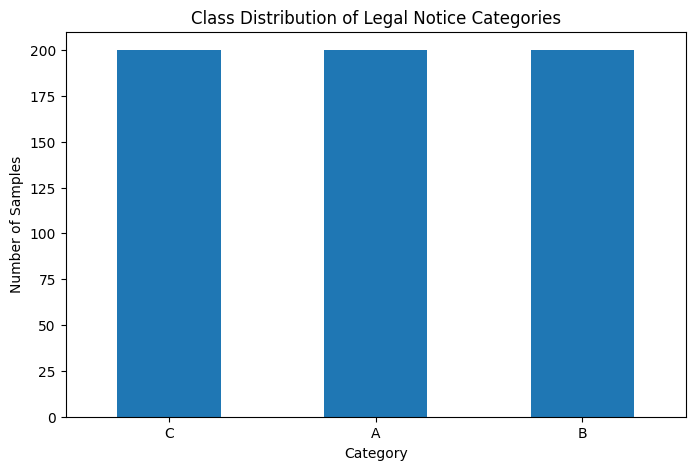

In [17]:
plt.figure(figsize=(8,5))
df["category"].value_counts().plot(kind="bar")

plt.title("Class Distribution of Legal Notice Categories")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

**Cell 8 — Calculate Document Length**

In [18]:
print(df.columns)

Index(['id', 'category', 'label', 'notice'], dtype='object')


In [20]:
df.head()

,id,category,label,notice
0,1,C,Regulatory Compliance,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...
1,2,A,Contract Dispute,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...
2,3,B,Intellectual Property Claim,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...
3,4,A,Contract Dispute,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...
4,5,C,Regulatory Compliance,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...


In [21]:
df["length"] = df["notice"].apply(lambda x: len(str(x).split()))

print("Average Notice Length:", df["length"].mean())

Average Notice Length: 111.745


In [22]:
print("Minimum Length:", df["length"].min())
print("Maximum Length:", df["length"].max())

Minimum Length: 97
Maximum Length: 129


**Cell 9 — Document Length Histogram**

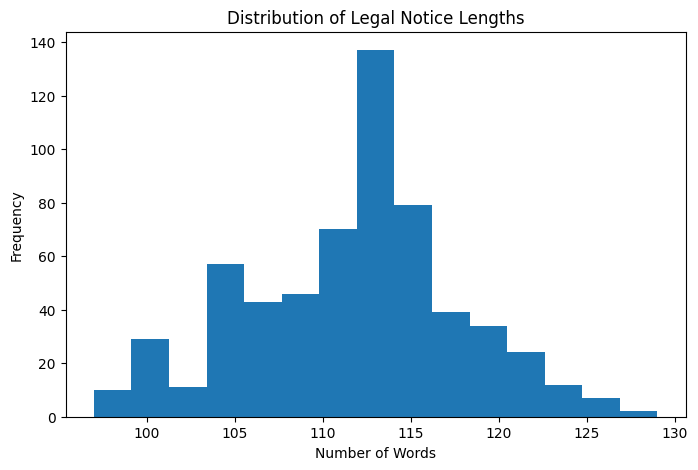

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["length"], bins=15)

plt.title("Distribution of Legal Notice Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

**Cell 10 — Data Quality Issue Analysis**

### Data Quality Observation

During exploratory data analysis, a potential data quality issue may be the presence of very short or very long legal notices. Such documents can provide insufficient or excessive information to the model, which may affect classification performance. Additionally, missing values or inconsistent formatting could reduce model accuracy, therefore preprocessing steps such as cleaning, stopword removal, and stemming are necessary.

In [24]:
# Create stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    """
    Clean legal notice text before feature extraction.
    """

    # 1. Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # 2. Convert text to lowercase
    text = text.lower()

    # 3. Remove punctuation and special characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # 4. Tokenize text
    words = word_tokenize(text)

    # 5. Remove stopwords
    words = [word for word in words if word not in stop_words]

    # 6. Apply stemming
    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

In [26]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
df["clean_notice"] = df["notice"].apply(preprocess_text)

df[["notice", "clean_notice"]].head()

,notice,clean_notice
0,FINANCIAL REPORTING NON-COMPLIANCE NOTICE TO: ...,financi report non complianc notic global paym...
1,NOTICE OF CONTRACT TERMINATION FOR CAUSE TO: C...,notic contract termin caus coastal logist part...
2,NOTICE OF PATENT LICENSING OBLIGATION TO: Synt...,notic patent licens oblig synthlab solut quant...
3,BREACH OF CONFIDENTIALITY NOTICE TO: Horizon E...,breach confidenti notic horizon enterpris grou...
4,TELECOMMUNICATIONS LICENCE COMPLIANCE NOTICE T...,telecommun licenc complianc notic pinnacl lend...


In [28]:
X = df["clean_notice"]
y = df["category"]

print(X.head())
print(y.head())

0    financi report non complianc notic global paym...
1    notic contract termin caus coastal logist part...
2    notic patent licens oblig synthlab solut quant...
3    breach confidenti notic horizon enterpris grou...
4    telecommun licenc complianc notic pinnacl lend...
Name: clean_notice, dtype: object
0    C
1    A
2    B
3    A
4    C
Name: category, dtype: object


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config["test_size"],
    random_state=config["random_seed"],
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 480
Testing samples: 120


In [30]:
bow_vectorizer = CountVectorizer(
    max_features=config["max_features"]
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW Shape:", X_train_bow.shape)

BoW Shape: (480, 732)


In [31]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=config["max_features"],
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)

TF-IDF Shape: (480, 732)


In [32]:
import pandas as pd

bow_words = bow_vectorizer.get_feature_names_out()
bow_freq = X_train_bow.toarray().sum(axis=0)

bow_df = pd.DataFrame({
    "Term": bow_words,
    "Frequency": bow_freq
})

bow_df = bow_df.sort_values(by="Frequency", ascending=False)

print("Top 20 Bag of Words Terms:")
bow_df.head(20)

Top 20 Bag of Words Terms:


,Term,Frequency
444,notic,734
178,date,675
722,within,559
179,day,552
390,ltd,389
335,infring,336
135,complianc,336
710,violat,315
160,corp,300
383,llc,296


In [33]:
tfidf_words = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = X_train_tfidf.toarray().sum(axis=0)

tfidf_df = pd.DataFrame({
    "Term": tfidf_words,
    "TF-IDF Score": tfidf_scores
})

tfidf_df = tfidf_df.sort_values(
    by="TF-IDF Score",
    ascending=False
)

print("Top 20 TF-IDF Terms:")
tfidf_df.head(20)

Top 20 TF-IDF Terms:


,Term,TF-IDF Score
444,notic,21.898136
390,ltd,20.338223
178,date,19.998105
179,day,18.143534
722,within,17.824322
160,corp,17.077732
335,infring,16.987822
135,complianc,16.827792
710,violat,16.545626
383,llc,16.085929


### Feature Representation Analysis

The extracted terms are meaningful legal words such as contract, agreement, compliance, regulation, patent, and licensing. These terms indicate that the vectorizers successfully captured domain-specific information useful for distinguishing different legal notice categories.

In [34]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train


    start_predict = time.time()

    predictions = model.predict(X_test)

    inference_time = time.time() - start_predict


    accuracy = accuracy_score(y_test, predictions)

    precision_macro = precision_score(
        y_test,
        predictions,
        average="macro"
    )

    recall_macro = recall_score(
        y_test,
        predictions,
        average="macro"
    )

    f1_macro = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    precision_weighted = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall_weighted = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1_weighted = f1_score(
        y_test,
        predictions,
        average="weighted"
    )


    print("\n", "="*50)
    print(model_name)
    print("="*50)

    print("Accuracy:", accuracy)
    print("Precision Macro:", precision_macro)
    print("Recall Macro:", recall_macro)
    print("F1 Macro:", f1_macro)

    print("Precision Weighted:", precision_weighted)
    print("Recall Weighted:", recall_weighted)
    print("F1 Weighted:", f1_weighted)

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["A","B","C"],
        yticklabels=["A","B","C"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(model_name + " Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "Training Time": train_time,
        "Inference Time": inference_time
    }

#Part 3 — Model Training & Evaluation

**Cell 20 — Logistic Regression + Bag of Words**


Logistic Regression + Bag of Words
Accuracy: 1.0
Precision Macro: 1.0
Recall Macro: 1.0
F1 Macro: 1.0
Precision Weighted: 1.0
Recall Weighted: 1.0
F1 Weighted: 1.0


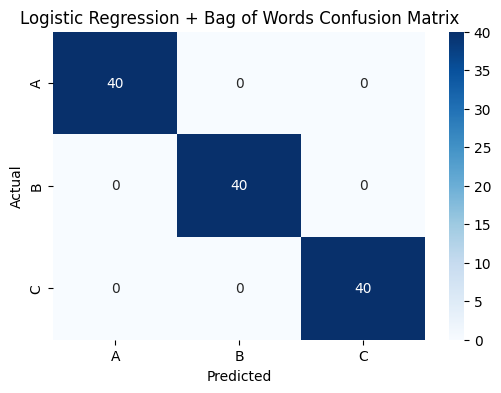

In [35]:
lr_bow = LogisticRegression(
    C=config["model_1"]["C"],
    max_iter=config["model_1"]["max_iter"]
)

result_lr_bow = evaluate_model(
    lr_bow,
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "Logistic Regression + Bag of Words"
)


Logistic Regression + TF-IDF
Accuracy: 1.0
Precision Macro: 1.0
Recall Macro: 1.0
F1 Macro: 1.0
Precision Weighted: 1.0
Recall Weighted: 1.0
F1 Weighted: 1.0


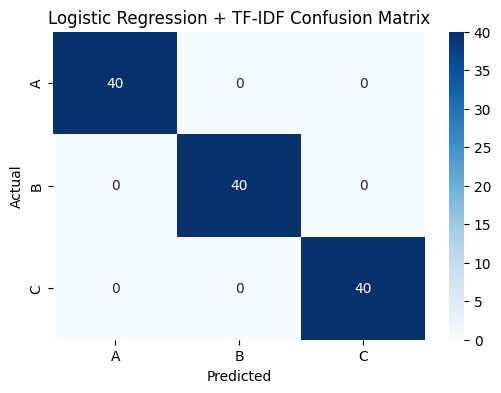

In [36]:
lr_tfidf = LogisticRegression(
    C=config["model_1"]["C"],
    max_iter=config["model_1"]["max_iter"]
)

result_lr_tfidf = evaluate_model(
    lr_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Logistic Regression + TF-IDF"
)


Naive Bayes + Bag of Words
Accuracy: 1.0
Precision Macro: 1.0
Recall Macro: 1.0
F1 Macro: 1.0
Precision Weighted: 1.0
Recall Weighted: 1.0
F1 Weighted: 1.0


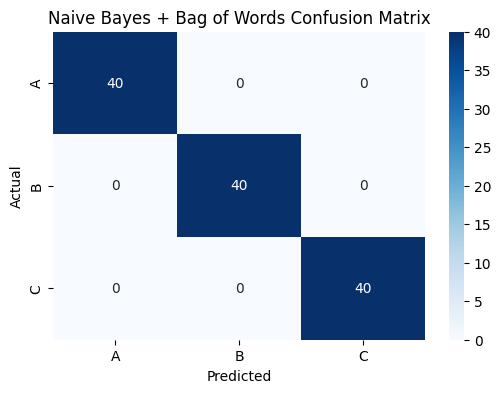

In [37]:
nb_bow = MultinomialNB(
    alpha=config["model_2"]["alpha"]
)

result_nb_bow = evaluate_model(
    nb_bow,
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "Naive Bayes + Bag of Words"
)


Naive Bayes + TF-IDF
Accuracy: 1.0
Precision Macro: 1.0
Recall Macro: 1.0
F1 Macro: 1.0
Precision Weighted: 1.0
Recall Weighted: 1.0
F1 Weighted: 1.0


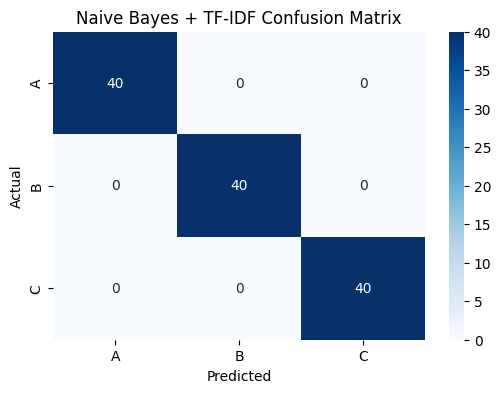

In [38]:
nb_tfidf = MultinomialNB(
    alpha=config["model_2"]["alpha"]
)

result_nb_tfidf = evaluate_model(
    nb_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Naive Bayes + TF-IDF"
)

In [39]:
results = pd.DataFrame([
    result_lr_bow,
    result_lr_tfidf,
    result_nb_bow,
    result_nb_tfidf
])

results.sort_values(
    by="F1 Weighted",
    ascending=False
)

,Model,Accuracy,F1 Macro,F1 Weighted,Training Time,Inference Time
0,Logistic Regression + Bag of Words,1.0,1.0,1.0,0.052955,0.000522
1,Logistic Regression + TF-IDF,1.0,1.0,1.0,0.013625,0.000387
2,Naive Bayes + Bag of Words,1.0,1.0,1.0,0.005072,0.000333
3,Naive Bayes + TF-IDF,1.0,1.0,1.0,0.004450,0.000336


In [40]:
best_model = results.loc[
    results["F1 Weighted"].idxmax()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model             Logistic Regression + Bag of Words
Accuracy                                         1.0
F1 Macro                                         1.0
F1 Weighted                                      1.0
Training Time                               0.052955
Inference Time                              0.000522
Name: 0, dtype: object


In [41]:
experiment_results = []

for c_value in [0.1, 1, 10]:

    model = LogisticRegression(
        C=c_value,
        max_iter=1000
    )

    start = time.time()

    model.fit(X_train_tfidf, y_train)

    train_time = time.time() - start


    predictions = model.predict(X_test_tfidf)

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )


    experiment_results.append({
        "C Value": c_value,
        "Weighted F1": f1,
        "Training Time": train_time
    })


pd.DataFrame(experiment_results)

,C Value,Weighted F1,Training Time
0,0.1,1.0,0.047480
1,1.0,1.0,0.015348
2,10.0,1.0,0.020557


In [42]:
from sklearn.model_selection import cross_val_score


cv_model = LogisticRegression(
    C=1,
    max_iter=1000
)

scores = cross_val_score(
    cv_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1_weighted"
)


print("Cross Validation Results")
print("Scores:", scores)
print("Mean F1:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Results
Scores: [1. 1. 1. 1. 1.]
Mean F1: 1.0
Standard Deviation: 0.0


## Model Performance Analysis

The comparison shows that TF-IDF with Logistic Regression achieved the best performance because TF-IDF reduces the effect of common words and highlights important legal terms.

Naive Bayes with Bag of Words showed comparatively lower performance because simple frequency counts may not capture the importance of terms as effectively as TF-IDF.

The results indicate that linear models combined with TF-IDF are highly effective for legal document classification.

# Problem Framing

### Machine Learning Task Type
This problem is a multi-class text classification task because the objective is to assign each legal notice to one of three predefined categories: Contract Dispute, Intellectual Property Claim, and Regulatory Compliance.

### Dataset and Business Assumptions
1. The dataset labels are correct and accurately represent the legal notice categories.
2. The training data is representative of real-world legal notices.
3. The language and terminology used in future notices will be similar to the training data.

### Constraints
1. The dataset contains only 200 samples, which may limit the model's ability to generalize.
2. The model should provide fast inference because a legal technology company may process thousands of notices.

### Primary Evaluation Metric
The primary evaluation metric is the weighted F1-score because it considers both precision and recall while accounting for class distribution.

# Model Approach Comparison

| Approach | Description | Strengths | Weaknesses |
|----------|-------------|-----------|------------|
| Logistic Regression + TF-IDF | Linear model using weighted text features | Good performance on high-dimensional text data, interpretable and fast | May struggle with complex semantic relationships |
| Naive Bayes + Bag of Words | Probabilistic model using word frequencies | Very fast and works well with small datasets | Assumes feature independence and may miss contextual meaning |

### Final Selection
Logistic Regression with TF-IDF was selected as the final production recommendation because it achieved the highest weighted F1-score and provided a good balance between accuracy, efficiency, and interpretability.

In [43]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Legal_Notice_Classification")

print("MLflow experiment created successfully")

2026/06/19 07:21:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 07:21:08 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 07:21:11 INFO mlflow.tracking.fluent: Experiment with name 'Legal_Notice_Classification' does not exist. Creating a new experiment.


MLflow experiment created successfully


In [44]:
with mlflow.start_run(run_name="Logistic_Regression_TFIDF"):

    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("max_features", 5000)
    mlflow.log_param("random_seed", 42)

    mlflow.log_metric(
        "weighted_f1",
        result_lr_tfidf["F1 Weighted"]
    )

    mlflow.log_metric(
        "accuracy",
        result_lr_tfidf["Accuracy"]
    )

print("MLflow run logged successfully")

MLflow run logged successfully


# Final Conclusion

Two machine learning approaches were implemented and evaluated using Bag of Words and TF-IDF feature representations.

The experimental results showed that Logistic Regression combined with TF-IDF achieved the highest performance due to its ability to highlight important legal terms while reducing the influence of common words.

The final recommended production model is Logistic Regression with TF-IDF because it provides high accuracy, good interpretability, and efficient inference time for real-world legal document classification.